# Temperature Dynamics

***
## Modelling the temperature $T_t$: Overview

By assumption, the daily temperature $T_t$ follows the model:

$$T_t = \theta_t + X_t \tag{1}$$

Where:

* **$\theta_t$**: the deterministic component of temperature (the summer/winter seasonal
alternation across years). It is modelled by a Fourier series (with $\omega = 2\pi/365.25$):

$$\theta_t = A + Bt + \sum_{k=1}^N \left( a_k \sin(k\omega t) + b_k \cos(k\omega t) \right) \tag{2}$$

As shown in `2_data_analysis_update.ipynb`, the mean temperature increases over time, which may be driven by
several factors such as climate change and urbanisation.

* **$X_t$**: the stochastic component, modelled by an Ornstein-Uhlenbeck process centred at zero:

$$dX_t = -\kappa X_t \, dt + \sigma_t \, dW_t \tag{3}$$

With:
- $\kappa > 0$: the mean-reversion speed. $X_t$ converges in expectation to 0
  ($\lim_{t \to \infty} \mathbb{E}[X_t] = 0$), which implies $T_t$ converges to $\theta_t$.
- $\sigma_t$: the seasonal volatility of the process (estimated in the next notebook).
- $W_t$: a standard Wiener process.

Substituting $dX_t = dT_t - d\theta_t$ into equation (3) yields the full dynamics of $T_t$:

$$dT_t = \left(\theta_t' + \kappa (\theta_t - T_t)\right) dt + \sigma_t \, dW_t \tag{4}$$

The goals of this part are therefore:
1. Find the order $N$ of the Fourier series for $\theta_t$ in each city and estimate its
   parameters by least squares.
2. Validate the OU specification by checking that an AR(1) structure is compatible with the
   ACF of the deseasonalized residuals $\hat{X}_t = T_t - \hat{\theta}_t$, then estimate $\kappa$.
3. Estimate $\sigma_t$ 

## Data split

Estimation follows the **frozen project window** (see `src/config.py`):

- **Estimation: 1950-01-01 → 2019-12-31** (70 years). $\theta$, $\kappa$ and $\sigma_X$ are
  estimated there, then **applied to the full history** (the trend is extrapolated after 2019,
  a documented assumption with negligible impact over ~6 years).
- **Test / app: 2020-01-01 → end of data**, never used for estimation.
- there is **no separate validation period**. The Fourier order $N$ is selected by AIC/BIC
  **on the estimation window** (Gaussian OLS likelihood), and forecasting models are validated
  by nested CV (see `5_ML_Evaluation&MC.ipynb`).

The whole estimation chain lives in `src/ou_pipeline.py`. This notebook calls it and
illustrates each step.

In [ ]:
import sys; sys.path.append("../../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from config import TRAIN_END, CITIES_RAW_DIR
from ou_pipeline import (load_and_clean, impute_dat, add_features,
                         fit_theta, estimate_kappa)
from ou_simulation import load_ou_params
from temperature_mc import ALL_CITIES

plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})

FOCUS = "Chicago"
df = add_features(impute_dat(load_and_clean(CITIES_RAW_DIR / f"{FOCUS}.csv")))
est_mask = df["DATE"] <= pd.Timestamp(TRAIN_END)
print(f"{FOCUS}: {len(df):,} days | estimation on {est_mask.sum():,} days (→ {TRAIN_END})")

Chicago: 27,741 days | estimation on 25,550 days (→ 2019-12-31)


## Selecting the Fourier order

We build the design matrix $X$ whose rows correspond to a time $t$ and contain the
explanatory variables:

$$x_t = \begin{bmatrix} 1 & t & \cos(\omega t) & \sin(\omega t) & \dots & \cos(N\omega t) & \sin(N\omega t) \end{bmatrix}$$

We also define the column vector of coefficients $\beta$:

$$\beta = \begin{bmatrix} A & B & a_1 & b_1 & \dots & a_N & b_N \end{bmatrix}^T$$

So that, across all observations, the model is written in matrix form:

$$\boldsymbol{\theta} = X\beta$$

Parameters are estimated by Ordinary Least Squares (OLS), which minimizes, with
respect to $\beta$, the sum of squared residuals (the squared norm $\|Y - X\beta\|^2$):

$$\hat{\beta} = \arg\min_{\beta} \|Y - X\beta\|^2$$

*(Note: in our model, the vector $Y$ is the vector of observed temperatures $T$.)*

To find the ideal order $N$ of the Fourier series, we look for the one that fits the
data best without *overfitting*. We use the Akaike Information Criterion (AIC) and the
Bayesian Information Criterion (BIC):

$$AIC = -2\ln(\hat{L}) + 2k$$
$$BIC = -2\ln(\hat{L}) + k\ln(n)$$

The first term rewards goodness of fit while the second penalizes model complexity. With
$n \approx 25\,550$ days of estimation, $\ln(n) \approx 10.1$, so BIC penalizes
additional parameters more heavily than AIC. We pick the order $N$ that minimizes one of
these criteria.

Each unit increase of the order $N$ adds one harmonic, i.e. 2 extra parameters ($a_N$ and
$b_N$). Including the intercept ($A$) and the linear trend ($B$), the total parameter count is
$k = 2N + 2$.

Let $x_1, \dots, x_n$ be our observations ($x_i = T_i - \theta_i$) with density:

$$\forall i \in [1,n], \quad f(x_i) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{x_i^2}{2\sigma^2}}$$

The likelihood function is:

$$L_n (x_1, \dots, x_n, \sigma) = \prod_{i=1}^n f(x_i) = \left(\frac{1}{\sigma \sqrt{2\pi}}\right)^n \exp\left({- \frac{1}{2\sigma^2} \sum_{i=1}^n x_i^2}\right)$$

Taking the log-likelihood $l_n(\sigma) = \log(L_n)$, given that the $(x_i)_n$ follow a normal
law $\mathcal{N}(0, \sigma^2)$:

$$l_n(\sigma) = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log(\sigma^2) - \frac{1}{2\sigma^2}\sum_{t=1}^n x_t^2$$

Maximizing over $\sigma$ ($\frac{\partial l(\sigma)}{\partial \sigma} = 0$) yields:

$$\hat{\sigma}^2 = \frac{1}{n}\sum_{t=1}^n x_t^2$$

Plugging the variance estimator $\hat{\sigma}^2$ back into the maximized log-likelihood, the
constant terms group together and we get the simplification:

$$\boxed{-2\log(\hat{L}_n) = n \log(\hat{\sigma}^2) + \text{constant}}$$

,AIC,BIC
order N,,
1,82638.3,82679.1
2,82253.5,82310.5
3,82178.1,82251.4
4,82175.3,82265.0
5,82168.4,82274.4
6,82137.8,82260.0


Selected order (BIC): N = 3


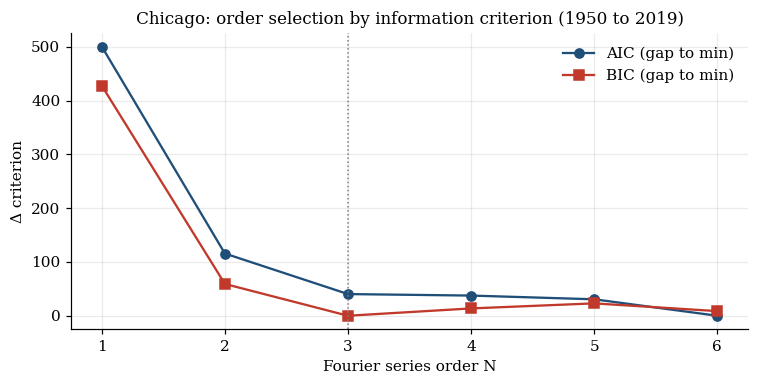

In [2]:
# Order selection on the estimation window: fit_theta tests 1..max_order
theta, best, table = fit_theta(df, est_mask, max_order=6, criterion="bic")
tab = pd.DataFrame(table, columns=["order N", "AIC", "BIC"]).set_index("order N").round(1)
display(tab)
print(f"Selected order (BIC): N = {best['order']}")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(tab.index, tab["AIC"] - tab["AIC"].min(), "o-", color="#1f4e79", label="AIC (gap to min)")
ax.plot(tab.index, tab["BIC"] - tab["BIC"].min(), "s-", color="#c0392b", label="BIC (gap to min)")
ax.axvline(best["order"], color="grey", ls=":", lw=1)
ax.set_xlabel("Fourier series order N"); ax.set_ylabel("Δ criterion")
ax.set_title(f"{FOCUS}: order selection by information criterion (1950 to 2019)")
ax.legend(frameon=False)
fig.tight_layout()

In [ ]:
# All 7 cities: selected order, read from the pipeline artifacts (no recomputation)
pd.DataFrame([{
    "city": c,
    "order N (BIC)": (p := load_ou_params(c))["theta_order"],
} for c in ALL_CITIES]).set_index("city")

,order N (BIC),kappa,phi = e^-kappa
city,,,
chicago,3,0.3317,0.7177
new_york,3,0.3908,0.6765
boston,3,0.4603,0.6311
minneapolis,3,0.2933,0.7458
dallas,3,0.3609,0.6970
los_angeles,5,0.2699,0.7634
seattle,4,0.2913,0.7473


The order minimizing our information criteria is $N=3$. This is somewhat surprising
relative to the existing literature.

For instance, in the reference work of Fred Espen Benth and Jūratė Šaltytė Benth (*Weather
Derivatives and Stochastic Modelling of Temperature*), an order $N=1$ is generally preferred.
A first-order Fourier model is much easier to interpret physically: it captures the basic
summer/winter alternation and can be rewritten as a single phase-shifted sinusoid:

$$\theta_t = A + Bt + C \sin(\omega t + \phi)$$

To understand why our model mathematically prefers a higher order, let us inspect the
empirical residuals $\hat{X}_t$ and visually compare order 1 against order 3:

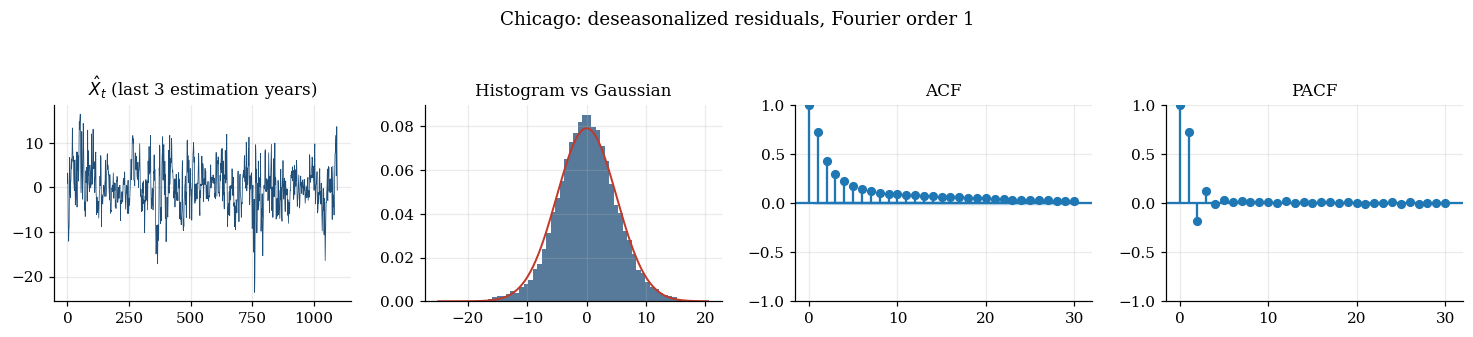

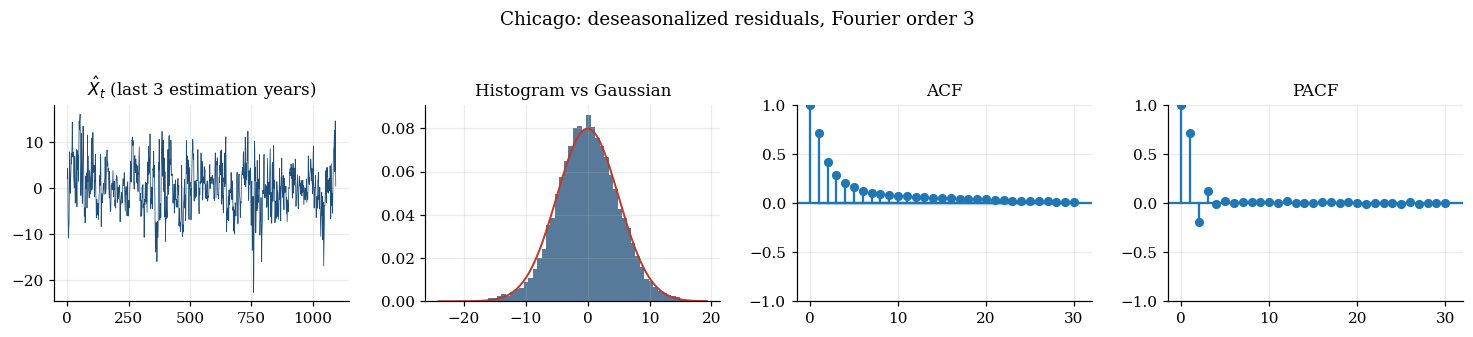

In [4]:
# Residual diagnostics for X_t = T - theta, order 1 vs selected order
def residual_diagnostics(df, est_mask, order, city):
    th, _, _ = fit_theta(df, est_mask, max_order=order, criterion="bic")
    X = (df["T"].to_numpy() - th)[est_mask.to_numpy()]
    fig, axes = plt.subplots(1, 4, figsize=(13.5, 2.9))
    axes[0].plot(X[-365*3:], lw=0.5, color="#1f4e79")
    axes[0].set_title("$\\hat{X}_t$ (last 3 estimation years)")
    axes[1].hist(X, bins=60, density=True, color="#1f4e79", alpha=0.75)
    from scipy.stats import norm
    g = np.linspace(X.min(), X.max(), 200)
    axes[1].plot(g, norm.pdf(g, X.mean(), X.std()), color="#c0392b", lw=1.3)
    axes[1].set_title("Histogram vs Gaussian")
    plot_acf(X, lags=30, ax=axes[2], title="ACF")
    plot_pacf(X, lags=30, ax=axes[3], title="PACF", method="ywm")
    fig.suptitle(f"{city}: deseasonalized residuals, Fourier order {order}", y=1.04)
    fig.tight_layout()

residual_diagnostics(df, est_mask, order=1, city=FOCUS)
residual_diagnostics(df, est_mask, order=best["order"], city=FOCUS)

Orders 1 and 3 lead to essentially the same picture:
- In the PACF, one significant spike at lag 1 and nothing beyond: the empirical signature of an
  AR(1) process, which validates the OU specification for $X_t$.
- In the ACF, a slow geometric decay, consistent with an AR(1) with a high coefficient.

The Fourier order does not affect the residual structure. We keep $N=3$ as selected by
AIC/BIC, noting that $N=1$ would produce structurally identical residuals. By seeing coeficients for N=3, we notice that the coefficients are very low for k=2 and 3, not very surprising that N=1 and 3 and very similar

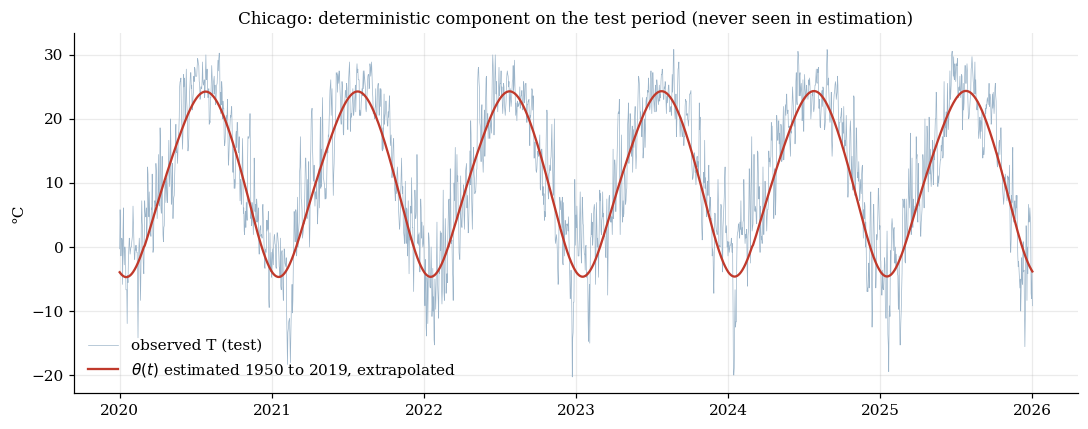

In [5]:
# theta overlaid on realized T, TEST period (2020+), where theta is EXTRAPOLATED
fig, ax = plt.subplots(figsize=(10, 4))
post = df[df["DATE"] > TRAIN_END].set_index("DATE")
th_post = theta[(df["DATE"] > pd.Timestamp(TRAIN_END)).to_numpy()]
ax.plot(post.index, post["T"], lw=0.45, color="#9bb4c9", label="observed T (test)")
ax.plot(post.index, th_post, lw=1.5, color="#c0392b",
        label="$\\theta(t)$ estimated 1950 to 2019, extrapolated")
ax.set_ylabel("°C")
ax.set_title(f"{FOCUS}: deterministic component on the test period (never seen in estimation)")
ax.legend(frameon=False)
fig.tight_layout()

## Estimating $\kappa$

Finding the mean-reversion speed $\kappa$ amounts to linking the AR(1) model identified
on the deseasonalized residuals.

By definition, an AR(1) process writes:

$$X_{t+1} = \phi X_t + \epsilon_t$$

**Euler-Maruyama approximation.** Setting $\Delta t = 1$ day, the Euler-Maruyama
discretization of equation (3) gives $dX_t \approx X_{t+1} - X_t$ and
$dW_t \approx W_{t+1} - W_t \sim \mathcal{N}(0, \Delta t = 1)$, replaced by a standard white
noise $\epsilon_t$. We obtain:

$$X_{t+1} - X_t = -\kappa X_t \,\Delta t + \sigma_t \epsilon_t$$

i.e., after rearranging:

$$X_{t+1} = (1 - \kappa) X_t + \sigma_t \epsilon_t$$

By identification with the AR(1), the approximate estimator follows:

$$\boxed{\hat{\kappa}_{\text{Euler}} = 1 - \hat{\phi}}$$

**Exact solution.** The analytical solution of the OU process between $t$ and $t+1$ follows
from variation of constants:

$$X_{t+1} = e^{-\kappa} X_t + \int_t^{t+1} e^{-\kappa(t+1-s)}\sigma_s \, dW_s$$

By identification, the exact AR(1) coefficient is $\phi = e^{-\kappa}$, hence:

$$\boxed{\hat{\kappa}_{\text{exact}} = -\ln(\hat{\phi})}$$

The two estimators coincide for $\phi$ close to 1 (slow mean reversion), but
$\kappa_{\text{exact}}$ is preferable as soon as $\phi$ is not small.

In [6]:
# kappa for the 7 cities, from artifacts. Euler vs exact comparison
rows = []
for c in ALL_CITIES:
    p = load_ou_params(c)
    phi = float(p["phi"]); kx = float(p["kappa"])
    ke = 1.0 - phi
    rows.append({"city": c, "phi": phi, "kappa exact = -ln(phi)": kx,
                 "kappa Euler = 1-phi": ke,
                 "relative gap (%)": 100 * abs(kx - ke) / kx,
                 "shock half-life (days)": np.log(2) / kx})
pd.DataFrame(rows).set_index("city").round(4)

,phi,kappa exact = -ln(phi),kappa Euler = 1-phi,relative gap (%),shock half-life (days)
city,,,,,
chicago,0.7177,0.3317,0.2823,14.8936,2.0897
new_york,0.6765,0.3908,0.3235,17.2266,1.7735
boston,0.6311,0.4603,0.3689,19.8569,1.5057
minneapolis,0.7458,0.2933,0.2542,13.3322,2.3629
dallas,0.6970,0.3609,0.3030,16.0580,1.9204
los_angeles,0.7634,0.2699,0.2366,12.3602,2.5678
seattle,0.7473,0.2913,0.2527,13.2482,2.3795


---
**Next.** The seasonal volatility $\sigma_X(\text{doy})$, the model's last parameter, is
estimated in `2_Volatility_models.ipynb`. Monte Carlo simulation under $\mathbb{P}$ and
$\mathbb{Q}$ and pricing are in `3_OU_Process.ipynb`. Each city's full parameter set
lives in `artifacts/{city}/v1/{city}_ou_params.joblib`.